In [1]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.1 MB/s eta 0:00:00


In [4]:
# Install and set up Kaggle
!pip install -q kaggle

from google.colab import files
uploaded = files.upload()  # Upload your kaggle.json here

# Move the API key to the correct location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [5]:
# Download the dataset
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
 99% 2.01G/2.04G [00:24<00:00, 359MB/s]
100% 2.04G/2.04G [00:24<00:00, 90.6MB/s]


In [6]:
# Extract the dataset and check nested structure
import zipfile
import os

# Unzip the dataset
with zipfile.ZipFile('plantvillage-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('plantvillage_dataset')

# Check the extracted structure
print("Dataset extracted. Checking structure...")
base_path = '/content/plantvillage_dataset'
print("Base path:", base_path)
print("\nAvailable folders:")
folders = os.listdir(base_path)
print(folders)

inner_folder = os.path.join(base_path, 'plantvillage dataset')
print(f"\nInner folder: {inner_folder}")
print("Contents of inner folder:")
inner_contents = os.listdir(inner_folder)
print(inner_contents)

# Check if there's a 'color' folder
color_folder = None
segmented_folder = None

for item in inner_contents:
    item_path = os.path.join(inner_folder, item)
    if os.path.isdir(item_path):
        if 'color' in item.lower():
            color_folder = item_path
        elif 'segmented' in item.lower():
            segmented_folder = item_path

print(f"\nColor folder found: {color_folder}")
print(f"Segmented folder found: {segmented_folder}")

Dataset extracted. Checking structure...
Base path: /content/plantvillage_dataset

Available folders:
['plantvillage dataset']

Inner folder: /content/plantvillage_dataset/plantvillage dataset
Contents of inner folder:
['color', 'segmented', 'grayscale']

Color folder found: /content/plantvillage_dataset/plantvillage dataset/color
Segmented folder found: /content/plantvillage_dataset/plantvillage dataset/segmented


In [7]:
# Set up the correct data directory
# We'll use the color images (not segmented/grayscale)
data_dir = color_folder if color_folder else inner_folder

print(f"\nUsing data directory: {data_dir}")

# List all class folders (should be 38)
import pathlib
data_dir_path = pathlib.Path(data_dir)
class_folders = [item.name for item in data_dir_path.iterdir() if item.is_dir()]
print(f"\nNumber of class folders found: {len(class_folders)}")
print("First 10 classes:")
for i, folder in enumerate(sorted(class_folders)[:10]):
    print(f"{i+1}. {folder}")

# Count total images
image_count = 0
for class_folder in class_folders:
    class_path = data_dir_path / class_folder
    images = list(class_path.glob('*.jpg')) + list(class_path.glob('*.JPG')) + list(class_path.glob('*.png'))
    image_count += len(images)
    if len(images) > 0:
        print(f"{class_folder}: {len(images)} images")

print(f"\nTotal images in dataset: {image_count}")


Using data directory: /content/plantvillage_dataset/plantvillage dataset/color

Number of class folders found: 38
First 10 classes:
1. Apple___Apple_scab
2. Apple___Black_rot
3. Apple___Cedar_apple_rust
4. Apple___healthy
5. Blueberry___healthy
6. Cherry_(including_sour)___Powdery_mildew
7. Cherry_(including_sour)___healthy
8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
9. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076 images
Cherry_(including_sour)___Powdery_mildew: 1052 images
Soybean___healthy: 5090 images
Peach___healthy: 360 images
Tomato___Late_blight: 1908 images
Cherry_(including_sour)___healthy: 854 images
Corn_(maize)___healthy: 1162 images
Squash___Powdery_mildew: 1835 images
Corn_(maize)___Common_rust_: 1192 images
Potato___healthy: 152 images
Strawberry___Leaf_scorch: 1109 images
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 5357 images
Apple___Black_rot: 621 images
Grape___Black_rot: 1180 images
Grape

In [2]:
from ultralytics import YOLO
import cv2
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
BASE_YOLO_DIR = "/content/leaf_yolo_dataset"

os.makedirs(f"{BASE_YOLO_DIR}/images/train", exist_ok=True)
os.makedirs(f"{BASE_YOLO_DIR}/images/val", exist_ok=True)
os.makedirs(f"{BASE_YOLO_DIR}/labels/train", exist_ok=True)
os.makedirs(f"{BASE_YOLO_DIR}/labels/val", exist_ok=True)


In [8]:
SOURCE_DIR = "/content/plantvillage_dataset/plantvillage dataset/color"
classes = os.listdir(SOURCE_DIR)

train_count = 0
val_count = 0

for class_name in classes:
    class_path = os.path.join(SOURCE_DIR, class_name)
    images = os.listdir(class_path)

    for i, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)

        if i % 5 == 0:
            split = "val"
            val_count += 1
        else:
            split = "train"
            train_count += 1

        # Copy image
        dest_img_path = f"{BASE_YOLO_DIR}/images/{split}/{class_name}_{img_name}"
        os.system(f"cp '{img_path}' '{dest_img_path}'")

        # Create label (leaf occupies full image)
        label_path = dest_img_path.replace("images", "labels").rsplit(".", 1)[0] + ".txt"

        with open(label_path, "w") as f:
            f.write("0 0.5 0.5 1.0 1.0\n")

print("Train images:", train_count)
print("Val images:", val_count)

Train images: 43429
Val images: 10876


In [9]:
data_yaml = f"""
path: {BASE_YOLO_DIR}
train: images/train
val: images/val

nc: 1
names: ["leaf"]
"""

with open(f"{BASE_YOLO_DIR}/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml created")

data.yaml created


In [10]:
yolo_model = YOLO("yolov8n.pt")   # nano version

In [11]:
yolo_model.train(
    data=f"{BASE_YOLO_DIR}/data.yaml",
    epochs=10,
    imgsz=640,
    batch=8
)

Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/leaf_yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plot

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fa3a6afa8d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [12]:
yolo_model = YOLO("runs/detect/train/weights/best.pt")

In [13]:
def draw_leaf_bbox(image_path):
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    results = yolo_model(image_rgb)

    for box in results[0].boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image_rgb, "Leaf", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)

    plt.figure(figsize=(6,6))
    plt.imshow(image_rgb)
    plt.axis("off")


0: 640x640 1 leaf, 14.3ms
Speed: 7.8ms preprocess, 14.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


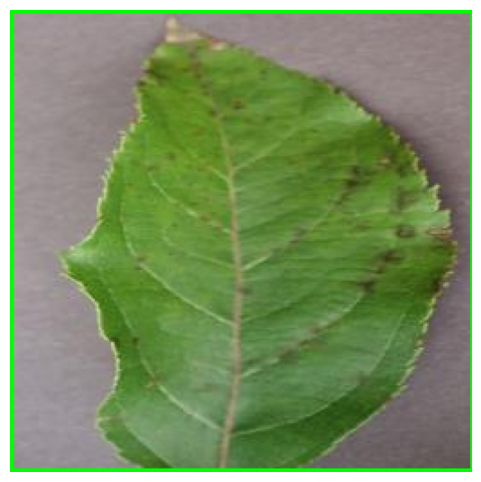

In [14]:
draw_leaf_bbox("/content/leaf.JPG")

In [17]:
def yolo_densenet_predict(image_path, densenet_model, class_names):
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    results = yolo_model(image_rgb)

    if len(results[0].boxes) == 0:
        crop = image_rgb
    else:
        box = results[0].boxes.xyxy[0].cpu().numpy()
        x1, y1, x2, y2 = map(int, box)
        crop = image_rgb[y1:y2, x1:x2]

    pil_img = Image.fromarray(crop)
    tensor = inference_transform(pil_img).unsqueeze(0).cuda()

    with torch.no_grad():
        out = densenet_model(tensor)
        _, pred = torch.max(out, 1)

    return class_names[pred.item()]


In [18]:
prediction = yolo_densenet_predict(
    "/content/leaf.JPG",
    model,
    dataset.classes
)

print("Predicted Disease:", prediction)


NameError: name 'model' is not defined